# Generation of a simple DFN with PorePy and Transfer to OGS

This is work in progress

In [1]:
import numpy as np
import porepy as pp
import ogstools as ogs

/home/mok/build/release2/.venv/lib/python3.12/site-packages/porepy/numerics/nonlinear/nonlinear_solvers.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange  # type: ignore


# Setting up the domain and generating a random set of circular fractures

In [2]:
mins = np.array([0.,0.,0.])
maxs = np.array([10.,10.,10.])

In [3]:
bounding_box = {'xmin': mins[0], 'xmax': maxs[0], 'ymin': mins[1], 'ymax': maxs[1], 'zmin': mins[2], 'zmax': maxs[2]}
domain = pp.Domain(bounding_box=bounding_box)
domain

pp.Domain(bounding_box={'xmin': 0.0, 'xmax': 10.0, 'ymin': 0.0, 'ymax': 10.0, 'zmin': 0.0, 'zmax': 10.0})

In [4]:
nfracs = 8
r_range = np.array([3,9])
f_i = np.array([])
for i in range(nfracs):
    center = np.random.rand(3) * (maxs - mins) + mins
    major_axis = np.random.rand() * (r_range[1] - r_range[0]) + r_range[0]
    minor_axis = major_axis.copy() #circular
    major_axis_angle = 0. #for circular
    strike_angle = np.random.rand() * np.pi - np.pi/2
    dip_angle = np.random.rand() * np.pi - np.pi/2
    f_i = np.append(f_i,pp.create_elliptic_fracture(center, major_axis, minor_axis, major_axis_angle, strike_angle, dip_angle))

In [5]:
network = pp.create_fracture_network(fractures=f_i,domain=domain)
network

Three-dimensional fracture network with 8 plane fractures.
The domain is a cuboid with bounding box: {'xmin': 0.0, 'xmax': 10.0, 'ymin': 0.0, 'ymax': 10.0, 'zmin': 0.0, 'zmax': 10.0}.

## Meshing ... 

In [6]:
mesh_args = {'cell_size_boundary': 1.0, 'cell_size_fracture': 0.5, 'cell_size_min': 0.2}
mdg = pp.create_mdg("simplex", mesh_args, network)
mdg

Mixed-dimensional grid containing 29 grids and 56 interfaces.
Maximum dimension present: 3 
Minimum dimension present: 0 
1 grids of dimension 3 with in total 79639 cells
8 grids of dimension 2 with in total 9118 cells
18 grids of dimension 1 with in total 132 cells
2 grids of dimension 0 with in total 2 cells
8 interfaces between grids of dimension 3 and 2 with in total 18236 mortar cells.
36 interfaces between grids of dimension 2 and 1 with in total 528 mortar cells.
12 interfaces between grids of dimension 1 and 0 with in total 12 mortar cells.

### Here I remove 3D mesh to visualize only 2D DFN

In [7]:
mdg2d = mdg.copy()
for sd in mdg2d.subdomains():
    if sd.dim == 3:
        mdg2d.remove_subdomain(sd)
mdg2d

Mixed-dimensional grid containing 28 grids and 48 interfaces.
Maximum dimension present: 2 
Minimum dimension present: 0 
8 grids of dimension 2 with in total 9118 cells
18 grids of dimension 1 with in total 132 cells
2 grids of dimension 0 with in total 2 cells
36 interfaces between grids of dimension 2 and 1 with in total 528 mortar cells.
12 interfaces between grids of dimension 1 and 0 with in total 12 mortar cells.

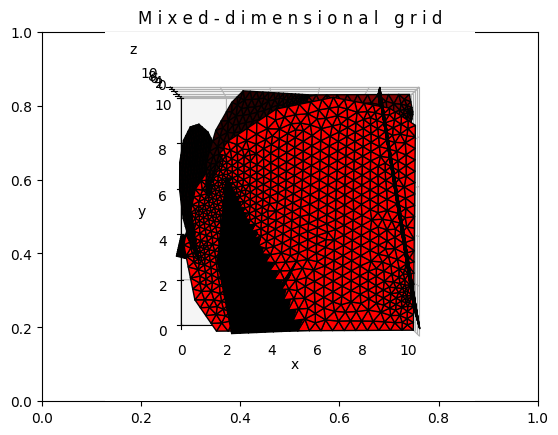

In [8]:
pp.plot_grid(mdg2d, figsize=(12,12), plot_2d=False)

## Export to VTU and import in OGS. Setting up Material IDs

In [9]:
pp.Exporter(mdg2d, 'mixed_dimensional_grid').write_vtu()

In [10]:
DFN_2D = ogs.Mesh('mixed_dimensional_grid_constant_2.vtu')
DFN_2D

Mesh (0x7f0f26d5b220)
  N Cells:    9118
  N Points:   5148
  X Bounds:   0.000e+00, 1.000e+01
  Y Bounds:   0.000e+00, 1.000e+01
  Z Bounds:   0.000e+00, 1.000e+01
  N Arrays:   6

In [11]:
DFN_2D['Material_ID'] = DFN_2D['subdomain_id'] - DFN_2D['subdomain_id'].min()

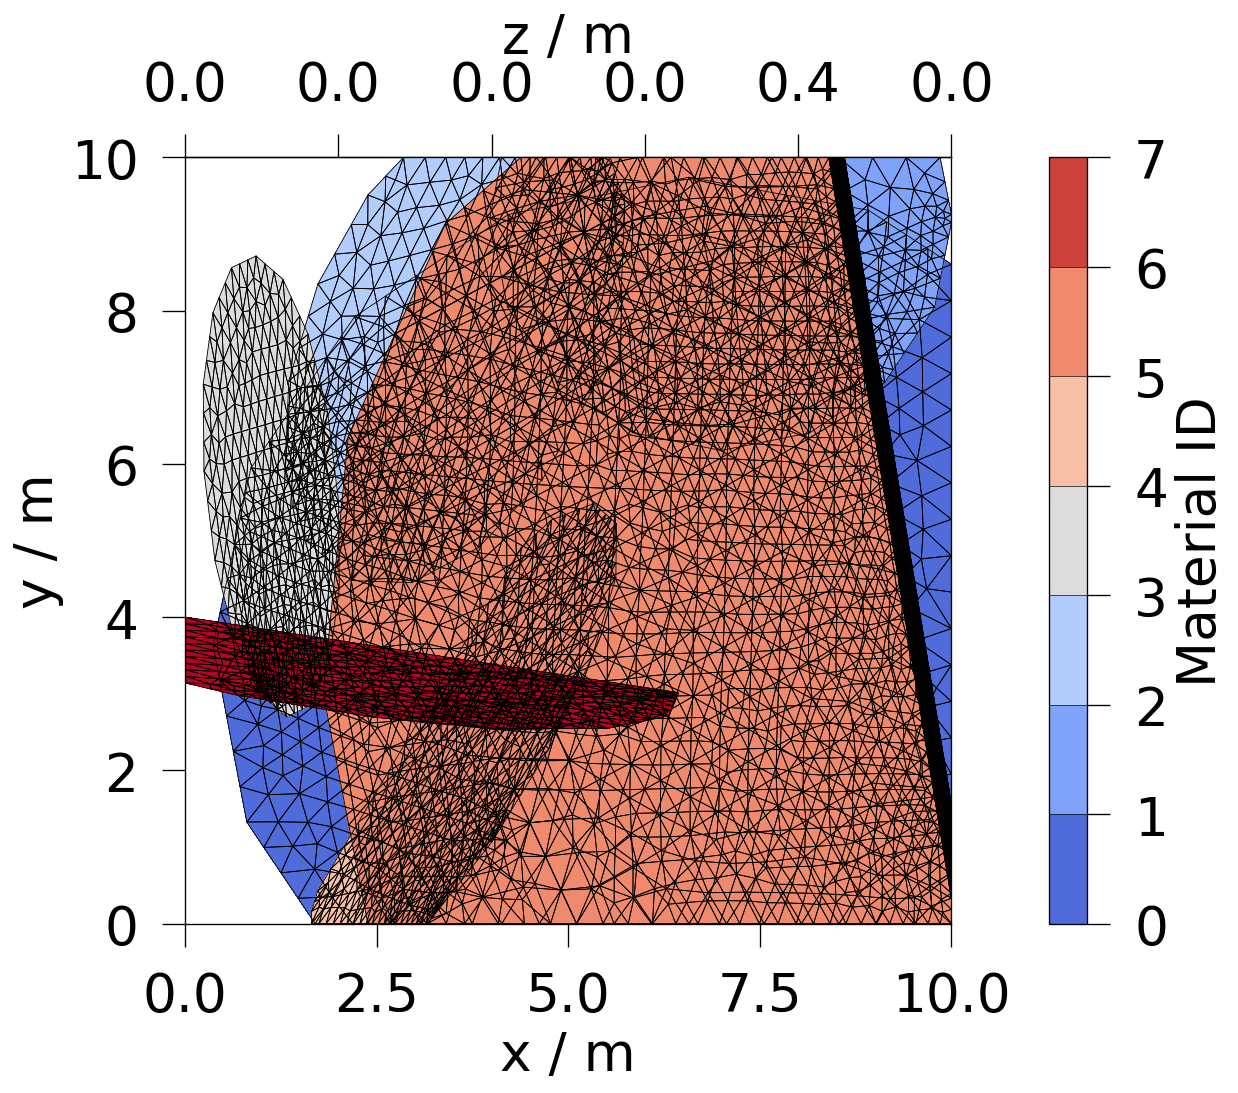

In [12]:
fig = DFN_2D.plot_contourf('Material_ID',show_edges=True)